# PB 223

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
df=pd.read_csv('student_scores.csv')
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [3]:
x=df[['Hours']]
y=df['Scores']
x.head()

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((20, 1), (5, 1), (20,), (5,))

In [5]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
m=lr.coef_
m

array([9.94061514])

In [7]:
c=lr.intercept_
c

np.float64(1.5079104828268726)

In [8]:
y_pred=lr.predict(x_test)
y_pred

array([12.44258714, 26.35944834, 20.39507925, 92.9615698 , 70.09815497])

In [9]:
print(f'MSE = {mean_squared_error(y_test,y_pred)}')

MSE = 24.38762033985666


# PB 228

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [11]:
df=pd.read_csv('winequality.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [12]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [13]:
y=df['quality']
x=df.drop(columns=['quality','Id'])

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((914, 11), (229, 11), (914,), (229,))

In [15]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
m=lr.coef_
m

array([ 5.13430654e-02, -1.33625691e+00, -3.39100758e-01,  4.12143173e-03,
       -1.80653035e+00,  1.88076181e-03, -2.28305818e-03, -3.06532562e+01,
       -2.49236344e-01,  9.73040097e-01,  2.66586068e-01])

In [17]:
c=lr.intercept_
c

np.float64(34.209805578378685)

In [18]:
lr.predict([[8,0.4,0.4,15,0.048,40,150,0.99,3,0.45,10.5]])

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5.80087585])

In [19]:
print(f"MSE = {mean_squared_error(y_test,lr.predict(x_test))}")
print(f"MAE = {mean_absolute_error(y_test,lr.predict(x_test))}")
print(f"r2 score = {r2_score(y_test,lr.predict(x_test))}")

MSE = 0.38003245026277577
MAE = 0.47733983525886037
r2 score = 0.3170693672733118


### PB 226

In [20]:
df=pd.read_csv('RealEstate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [21]:
df.isna().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [22]:
df.dtypes

No                                          int64
X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
Y house price of unit area                float64
dtype: object

In [23]:
df=df.drop(columns=['No'])
df.sample()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
14,2013.5,13.2,1164.838,4,24.99156,121.53406,34.3


In [24]:
y=df['Y house price of unit area']
x=df.drop(columns=['Y house price of unit area'])

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=110)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((289, 6), (125, 6), (289,), (125,))

In [26]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
m=lr.coef_
m

array([ 6.84308941e+00, -2.25466590e-01, -5.18046265e-03,  1.12369103e+00,
        1.87739728e+02, -4.29300312e+01])

In [28]:
c=lr.intercept_
c

np.float64(-13203.674300629986)

In [29]:
lr.predict(x_test)

array([40.06913335, 32.56470479, 29.80668902, 44.60809493, 39.96541473,
       44.34984726, 37.64834639, 51.18801909, 37.08044432, 38.64449437,
       36.45757424, 31.64776451, 43.03392987, 16.64984039, 36.61381207,
       31.21699197, 39.55333345, 41.89770923, 46.41953538, 42.69067202,
       40.49560609, 53.3447345 , 40.74436408, 36.67049204, 46.86499408,
       42.78349352, 47.25115307, 40.53653503, 42.57499139, 50.88772177,
       44.81813044, 41.05114011, 35.39386877, 42.95199941, 13.97578058,
       30.00463214,  0.32863779, 39.56884707, 47.9626967 , 34.0147913 ,
       40.23322474, 49.74492584, 36.73990519, 35.39784888, 29.6071314 ,
       45.83432319, 42.44745248, 37.88237609, 31.55675944, 47.517238  ,
       35.03089266, 45.17666152, 45.98711652, 47.32685806, 54.18178829,
       15.18888047, 43.78264851, 44.75385635, 37.69057227, 39.34215811,
       44.21812376, 44.27270068, 47.84570949, 38.42626454, 41.0626191 ,
       19.64522484, 47.9626967 , 43.85961508, 37.99756745, 43.80

In [30]:
print(f"MSE = {mean_squared_error(y_test,lr.predict(x_test))}")
print(f"MAE = {mean_absolute_error(y_test,lr.predict(x_test))}")
print(f"r2 score = {r2_score(y_test,lr.predict(x_test))}")

MSE = 77.14802598253691
MAE = 6.443245493782514
r2 score = 0.5447865064578771


# PB227

In [31]:
df=pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [32]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [33]:
df=pd.get_dummies(df,drop_first=True)
df.head()

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,False,True,False,False,True
1,18,33.8,1,1725.55,True,False,False,True,False
2,28,33.0,3,4449.46,True,False,False,True,False
3,33,22.7,0,21984.47,True,False,True,False,False
4,32,28.9,0,3866.86,True,False,True,False,False


In [34]:
y=df['expenses']
x=df.drop(columns=['expenses'])


In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1070, 8), (268, 8), (1070,), (268,))

In [36]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
m=lr.coef_
m

array([ 2.56955959e+02,  3.37271473e+02,  4.25641376e+02, -1.85197407e+01,
        2.36503123e+04, -3.70313511e+02, -6.58712382e+02, -8.09229878e+02])

In [38]:
c=lr.intercept_
c

np.float64(-11936.774427292205)

In [39]:
lr.predict(x_test)

array([ 8976.76760964,  7061.47078348, 36861.00837958,  9439.16742899,
       26965.82783567, 10866.56613365,   163.68342867, 16902.1625389 ,
        1092.78891435, 11221.84972563, 28100.81510083,  9381.37647426,
        5265.11298425, 38433.51445836, 40248.06655201, 37084.37888675,
       15248.12984097, 35901.53286407,  9127.45708271, 31464.93323459,
        3848.37001706, 10130.91497172,  2370.69195712,  7139.66129952,
       11294.96254187, 12967.62453886, 14509.58195129,  6160.69986604,
        9962.85959031,  2163.07205222,  9116.85372521, 13064.63457975,
        4571.36274084,  3423.94442545,  4460.1164586 , 13031.12862237,
        1979.67910034,  8813.16035987, 33258.81811961, 32584.31750912,
        3910.32992482,  4343.38905053, 14143.48952085, 11435.21647816,
        8791.14158849, 12096.4844327 ,  5272.59144805,  3150.51559564,
       35504.10915377,  9154.13549953, 15835.69309292,  2352.62339682,
       12359.83078765,  1472.69854255, 13377.66583865, 12570.20082856,
      

In [40]:
print(f"MSE = {mean_squared_error(y_test,lr.predict(x_test))}")
print(f"MAE = {mean_absolute_error(y_test,lr.predict(x_test))}")
print(f"r2 score = {r2_score(y_test,lr.predict(x_test))}")

MSE = 33600065.35507782
MAE = 4181.561524000788
r2 score = 0.7835726930039906


In [41]:
df.sample()

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
254,50,31.8,0,41097.16,True,True,False,False,False


In [42]:
lr.predict([[31,21.5,2,0,1,0,0,0]])

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([27781.79203199])

# 268

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

In [44]:
df=pd.read_csv('data_breast_cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [45]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [46]:
df=df.drop(columns=['id','Unnamed: 32'])
df.sample()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
8,M,13.0,21.82,87.5,519.8,0.1273,0.1932,0.1859,0.09353,0.235,...,15.49,30.73,106.2,739.3,0.1703,0.5401,0.539,0.206,0.4378,0.1072


In [47]:
x=df.drop(columns=['diagnosis'])
y=df['diagnosis']


In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [49]:
455**0.5

21.330729007701542

In [50]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(21)

In [51]:
model=nn.fit(x_train,y_train)

In [52]:
y_pred=model.predict(x_test)
y_pred

array(['B', 'M', 'M', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M',
       'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B',
       'B', 'M', 'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'B', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'B', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M'], dtype=object)

In [53]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[71,  0],
       [ 4, 39]])

In [54]:
tn=cm[0][0]
fp=cm[0][1]
fn=cm[1][0]
tp=cm[1][1]
tn,fn,tp,fp

(np.int64(71), np.int64(4), np.int64(39), np.int64(0))

In [55]:
accuracy=(tn+tp)/(tn+fn+fp+tp)
accuracy

np.float64(0.9649122807017544)

In [56]:
error_rate=(fn+fp)/(tn+fn+fp+tp)
error_rate

np.float64(0.03508771929824561)

In [57]:
sensitivity =tp/(tp+fn)
sensitivity

np.float64(0.9069767441860465)

In [58]:
specificity=tn/(tn+fp)
specificity

np.float64(1.0)

# tennis

In [59]:
import pandas as pd

In [60]:
df=pd.read_csv('PlayTennis.csv')
df.head()

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


In [61]:
ndf=pd.get_dummies(df.drop(columns=['play']),drop_first=True)
ndf['play']=df['play']
ndf.head()

,windy,outlook_rainy,outlook_sunny,temp_hot,temp_mild,humidity_normal,play
0,False,False,True,True,False,False,no
1,True,False,True,True,False,False,no
2,False,False,False,True,False,False,yes
3,False,True,False,False,True,False,yes
4,False,True,False,False,False,True,yes


In [62]:
y=ndf['play']
x=ndf.drop(columns=['play'])

In [63]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((11, 6), (3, 6), (11,), (3,))

In [64]:
11**0.5

3.3166247903554

In [65]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(3)

In [66]:
model=nn.fit(x_train,y_train)

In [67]:
y_pred=model.predict(x_test)
y_pred

array(['yes', 'no', 'yes'], dtype=object)

In [68]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[0, 1],
       [1, 1]])

In [69]:
tn=cm[0][0]
fp=cm[0][1]
fn=cm[1][0]
tp=cm[1][1]
tn,fn,tp,fp

(np.int64(0), np.int64(1), np.int64(1), np.int64(1))

In [70]:
accuracy=(tn+tp)/(tn+fn+fp+tp)
accuracy

np.float64(0.3333333333333333)

In [71]:
error_rate=(fn+fp)/(tn+fn+fp+tp)
error_rate

np.float64(0.6666666666666666)

In [72]:
sensitivity =tp/(tp+fn)
sensitivity

np.float64(0.5)

In [73]:
specificity=tn/(tn+fp)
specificity

np.float64(0.0)

In [74]:
ndf.sample()

,windy,outlook_rainy,outlook_sunny,temp_hot,temp_mild,humidity_normal,play
0,False,False,True,True,False,False,no


In [75]:
# rainy=1
# temp=cool
# humdit=high
# windy
nn.predict([[1,1,0,0,0,0]])

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['no'], dtype=object)

# Fish 

In [76]:
df=pd.read_csv('Fish.csv')
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [77]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [78]:
y=df['Species']
x=df.drop(columns=['Species'])


In [79]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((127, 6), (32, 6), (127,), (32,))

In [80]:
127**0.5

11.269427669584644

In [81]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(11)

In [82]:
model=nn.fit(x_train,y_train)

In [83]:
y_pred=model.predict(x_test)
y_pred

array(['Perch', 'Smelt', 'Roach', 'Perch', 'Roach', 'Perch', 'Smelt',
       'Roach', 'Roach', 'Perch', 'Bream', 'Perch', 'Bream', 'Roach',
       'Bream', 'Perch', 'Perch', 'Perch', 'Perch', 'Bream', 'Smelt',
       'Bream', 'Bream', 'Bream', 'Perch', 'Perch', 'Roach', 'Perch',
       'Smelt', 'Smelt', 'Bream', 'Perch'], dtype=object)

In [84]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[7, 0, 3, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0],
       [0, 0, 6, 0, 3, 0, 0],
       [1, 0, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 5, 0],
       [0, 0, 3, 0, 0, 0, 0]])

In [85]:
# tn, fp, fn, tp = cm.ravel()


In [86]:
#weight=85,l1=25,l2=20,l3=31,h=6,w=2.5
model.predict([[85,25,20,31,6,2.5]])


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Perch'], dtype=object)

In [87]:
df=pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [88]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [89]:
df=df.drop(columns=['Id'])

In [90]:
x=df.drop(columns=['Species'])
y=df['Species']

In [91]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((80, 4), (20, 4), (80,), (20,))

In [92]:
80**0.5

8.94427190999916

In [93]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(9)


In [94]:
model=nn.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array(['Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-setosa'], dtype=object)

In [95]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[12,  0],
       [ 0,  8]])

tn=cm[0][0]
fp=cm[0][1]
fn=cm[1][0]
tp=cm[1][1]
tn,fn,tp,fp

In [96]:
accuracy=(tn+tp)/(tn+fn+fp+tp)
accuracy

np.float64(0.3333333333333333)

In [97]:
error_rate=(fn+fp)/(tn+fn+fp+tp)
error_rate

np.float64(0.6666666666666666)

In [98]:
sensitivity =tp/(tp+fn)
sensitivity

np.float64(0.5)

In [99]:
specificity=tn/(tn+fp)
specificity

np.float64(0.0)

## 201

In [100]:
import numpy as np
X_train = np.array([[1], [2], [3], [4]])
y_train = np.array([2, 4, 6, 8])
# Test data
X_test = np.array([[5]])
# Linear regression model
model = LinearRegression( )
model.fit(X_train, y_train)
predicted_value = model.predict(X_test)
print(predicted_value)

[10.]


# 230

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
import matplotlib.pyplot as plt

In [150]:
df=pd.read_csv('windpower - Copy.csv')
df.sample(5)

,Power (kW),Wind speed (m/s)
105,0.000,5.556
2,0.000,0.150
486,93.694,24.299
185,9.911,9.560
377,87.986,18.869


In [151]:
df.isna().sum()

Power (kW)          3
Wind speed (m/s)    5
dtype: int64

In [152]:
df=df.dropna()
df.isna().sum()

Power (kW)          0
Wind speed (m/s)    0
dtype: int64

In [153]:
x=df[['Wind speed (m/s)']]
y=df['Power (kW)']

In [154]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((369, 1), (123, 1), (369,), (123,))

In [155]:
from sklearn.preprocessing import PolynomialFeatures


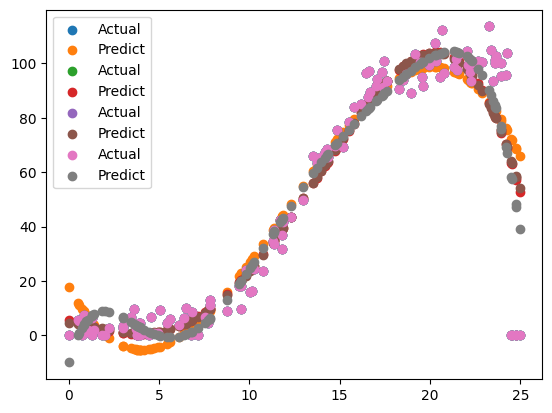

In [156]:
dic={}
for i in [3,4,5,6]:
    poly=PolynomialFeatures(degree=i)
    xtrain_poly=poly.fit_transform(x_train)
    lr=LinearRegression()
    lr.fit(xtrain_poly,y_train)
    m=lr.coef_
    c=lr.intercept_
    p=lr.predict(poly.transform(x_test))
    MSE = mean_squared_error(y_test,lr.predict(poly.transform(x_test)))
    MAE = mean_absolute_error(y_test,lr.predict(poly.transform(x_test)))
    r2_scoree = r2_score(y_test,lr.predict(poly.transform(x_test)))
    dic[i]=[m,c,MSE,MAE,r2_scoree,p]
    plt.scatter(x_test,y_test,label='Actual')
    plt.scatter(x_test,p,label='Predict')
plt.legend()
plt.show()

In [157]:
x=[]
y=[]
pv=[]
yy=[]
for i in dic:
    print(f"Degree={i},MSE={dic[i][2]},R2={dic[i][4]}")
    x.append(i)
    yy.append(y_test)
    y.append(dic[i][2])
    pv.append(dic[i][-1])
    
plt.show()

Degree=3,MSE=270.0250095299955,R2=0.8539264141973832
Degree=4,MSE=209.3184510784717,R2=0.8867664266472862
Degree=5,MSE=212.4228861347375,R2=0.8850870416105098
Degree=6,MSE=169.170104193283,R2=0.9084852037478769


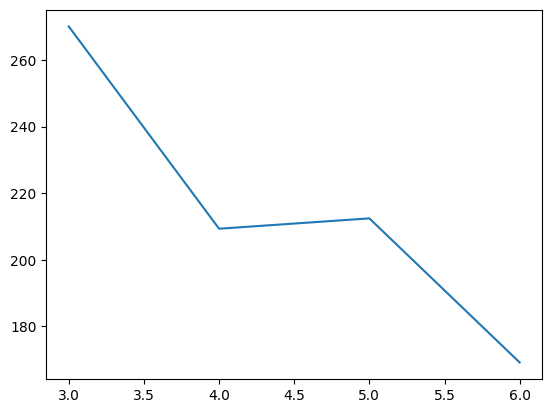

In [158]:
plt.plot(x,y)
plt.show()

# DIABETES 

In [113]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,recall_score


In [114]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [115]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [116]:
y=df['Outcome']
x=df.drop(columns=['Outcome'])

In [117]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [118]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
model=DecisionTreeClassifier(criterion='entropy',max_depth=25,random_state=42)
model

,criterion,'entropy'
,splitter,'best'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [119]:
model.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [120]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0])

In [121]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[76, 23],
       [20, 35]])

In [122]:
tn=cm[0][0]
fp=cm[0][1]
fn=cm[1][0]
tp=cm[1][1]
tn,fn,tp,fp

(np.int64(76), np.int64(20), np.int64(35), np.int64(23))

In [123]:
accuracy=(tn+tp)/(tn+fn+fp+tp)
accuracy

np.float64(0.7207792207792207)

In [124]:
error_rate=(fn+fp)/(tn+fn+fp+tp)
error_rate

np.float64(0.2792207792207792)

In [125]:
sensitivity =tp/(tp+fn)
sensitivity

np.float64(0.6363636363636364)

In [126]:
specificity=tn/(tn+fp)
specificity

np.float64(0.7676767676767676)

In [127]:
precision=tp/(tp+fp)
precision

np.float64(0.603448275862069)

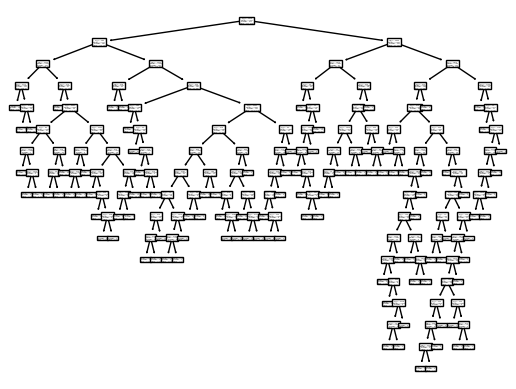

In [128]:
import matplotlib.pyplot as plt
plot_tree(model)
plt.show()

In [129]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154

